In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.models as models
import torchvision.transforms as transforms

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    adjusted_rand_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from pathlib import Path

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

Device : cuda


In [20]:
DATA_DIR = Path(".")

train_df = pd.read_csv(DATA_DIR / "pseudo_labels_gmm.csv")
test_df = pd.read_csv(DATA_DIR / "true_labels_test.csv")

print(f"Train (pseudo-labels) : {len(train_df)} images")
print(f"  cancer (1) : {(train_df['label'] == 1).sum()}")
print(f"  normal (0) : {(train_df['label'] == 0).sum()}\n")

print(f"Test  (vrais labels)  : {len(test_df)} images")
print(f"  cancer (1) : {(test_df['label'] == 1).sum()}")
print(f"  normal (0) : {(test_df['label'] == 0).sum()}")

train_df

Train (pseudo-labels) : 1406 images
  cancer (1) : 787
  normal (0) : 619

Test  (vrais labels)  : 100 images
  cancer (1) : 50
  normal (0) : 50


,image_path,label,proba_cancer,proba_normal
0,data\sans_label\001b158a-7af8-451e-bf31-3a9116...,1,1.0,0.0
1,data\sans_label\00366e8d-5520-4d3c-a70b-91a7ee...,0,0.0,1.0
2,data\sans_label\00455a62-f79f-4072-9a23-4951e7...,0,0.0,1.0
3,data\sans_label\004ce5f5-ca6b-490f-9b2f-c322c1...,1,1.0,0.0
4,data\sans_label\005d9a37-8894-4eb5-8367-1015d4...,1,1.0,0.0
...,...,...,...,...
1401,data\sans_label\ff3d5248-a7a7-47f6-8fe4-a44a45...,1,1.0,0.0
1402,data\sans_label\ff93375a-a8ea-4c44-9679-8b62ff...,0,0.0,1.0
1403,data\sans_label\ffab85a5-cdb8-4c32-aa75-926199...,0,0.0,1.0
1404,data\sans_label\ffae953a-1429-4a56-a258-7c4c01...,1,1.0,0.0


# Split du test set (70/30) --> 50/50

In [21]:
from sklearn.model_selection import train_test_split

# 80/20 stratified split on the labeled test set (50 cancer / 50 normal)
labeled_test_df, labeled_val_df = train_test_split(
    test_df,
    test_size=0.6,
    stratify=test_df["label"],
    random_state=42,
)

print(
    f"Labeled test : {len(labeled_test_df)} images  "
    f"(cancer={( labeled_test_df['label']==1).sum()}, "
    f"normal={(labeled_test_df['label']==0).sum()})"
)
print(
    f"Labeled val   : {len(labeled_val_df)} images  "
    f"(cancer={(labeled_val_df['label']==1).sum()}, "
    f"normal={(labeled_val_df['label']==0).sum()})"
)

Labeled test : 40 images  (cancer=20, normal=20)
Labeled val   : 60 images  (cancer=30, normal=30)


# Fonction Evaluate

In [22]:
def evaluate(y_true, y_pred, title="Évaluation"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    ari = adjusted_rand_score(y_true, y_pred)

    print(f"{'─'*40}")
    print(f"  {title}")
    print(f"{'─'*40}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-score  : {f1:.4f}")
    print(f"  F2-score  : {f2:.4f}")
    print(f"  ARI       : {ari:.4f}")
    print(f"{'─'*40}\n")

    fig, ax = plt.subplots(figsize=(4, 4))
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred),
        display_labels=["Normal (0)", "Cancer (1)"],
    ).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "f2": f2,
        "ari": ari,
    }


print("Fonction evaluate() prête.")

Fonction evaluate() prête.


# Création des datasets et dataloaders

In [23]:
# Inference transforms — no augmentation, just resize + ImageNet normalization
TRANSFORMS = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)


class MRIset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        with Image.open(self.df.iloc[idx]["image_path"]) as img:
            if self.transform:
                img = self.transform(img)
        label = self.df.iloc[idx]["label"]
        return img, label


dataset_weak = MRIset(train_df, transform=TRANSFORMS)
dataset_test = MRIset(labeled_test_df, transform=TRANSFORMS)
dataset_val = MRIset(labeled_val_df, transform=TRANSFORMS)

loader_weak = DataLoader(dataset_weak, batch_size=32, shuffle=True)
loader_test = DataLoader(dataset_test, batch_size=16, shuffle=True)
loader_val = DataLoader(
    dataset_val, batch_size=16, shuffle=False
)  # on false le shuffle pour garder l'ordre des images (pour le CSV de sortie)

# EFNET + CNN sur labels faibles

In [24]:
class ClassifierHead(nn.Module):
    def __init__(self, in_features=1792, num_classes=2, dropout=0.4):
        super().__init__()
        self.head = nn.Sequential(
            nn.Dropout(p=dropout),           # same dropout as original EfficientNet-B4
            nn.Linear(in_features, num_classes),
        )

    def forward(self, x):
        return self.head(x)


myCNN = ClassifierHead().to(DEVICE)

In [25]:
# Load efficientnet pretrained, remove the final classification layer
model = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1)
model.classifier = myCNN
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()

# Freeze backbone, train head only
for param in model.parameters():
    param.requires_grad = False
for param in model.classifier.parameters():
    param.requires_grad = True

# Only pass trainable parameters to avoid allocating Adam state for frozen weights
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=0.001
)

for epoch in range(10):
    model.train()
    for imgs, labels in loader_weak:
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE).long()
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

## Evaluation sur le set de test (pour comparaison avec clustering)

────────────────────────────────────────
  EfficientNet-B4 — Test set (phase intermediaire)
────────────────────────────────────────
  Accuracy  : 0.8000
  Precision : 0.9167
  Recall    : 0.6600
  F1-score  : 0.7674
  F2-score  : 0.6992
  ARI       : 0.3540
────────────────────────────────────────



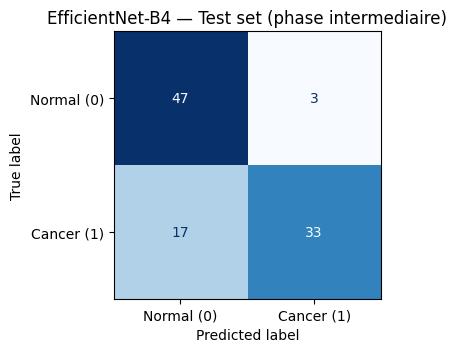

In [26]:
loader_temp = DataLoader(MRIset(test_df, transform=TRANSFORMS), batch_size=8, shuffle=False)

all_preds_temp = []
all_labels_temp = []

model.eval()
with torch.no_grad():
    for imgs, labels in loader_temp:
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)
        all_preds_temp.extend(preds.cpu().numpy())
        all_labels_temp.extend(labels.cpu().numpy())

results = evaluate(all_labels_temp, all_preds_temp, title="EfficientNet-B4 — Test set (phase intermediaire)")

## Evaluation sur le set de validation

In [27]:
torch.save(model.state_dict(), "model_phase1.pth")

In [28]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for imgs, labels in loader_val:
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

────────────────────────────────────────
  EfficientNet-B4 — Val set (phase 1)
────────────────────────────────────────
  Accuracy  : 0.8000
  Precision : 0.9500
  Recall    : 0.6333
  F1-score  : 0.7600
  F2-score  : 0.6786
  ARI       : 0.3502
────────────────────────────────────────



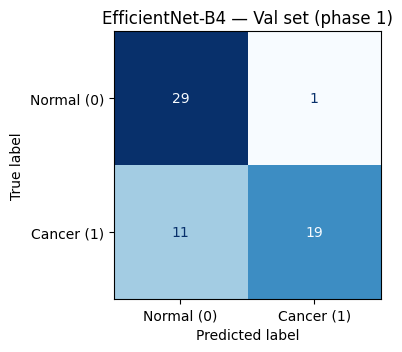

In [29]:
results = evaluate(all_labels, all_preds, title="EfficientNet-B4 — Val set (phase 1)")


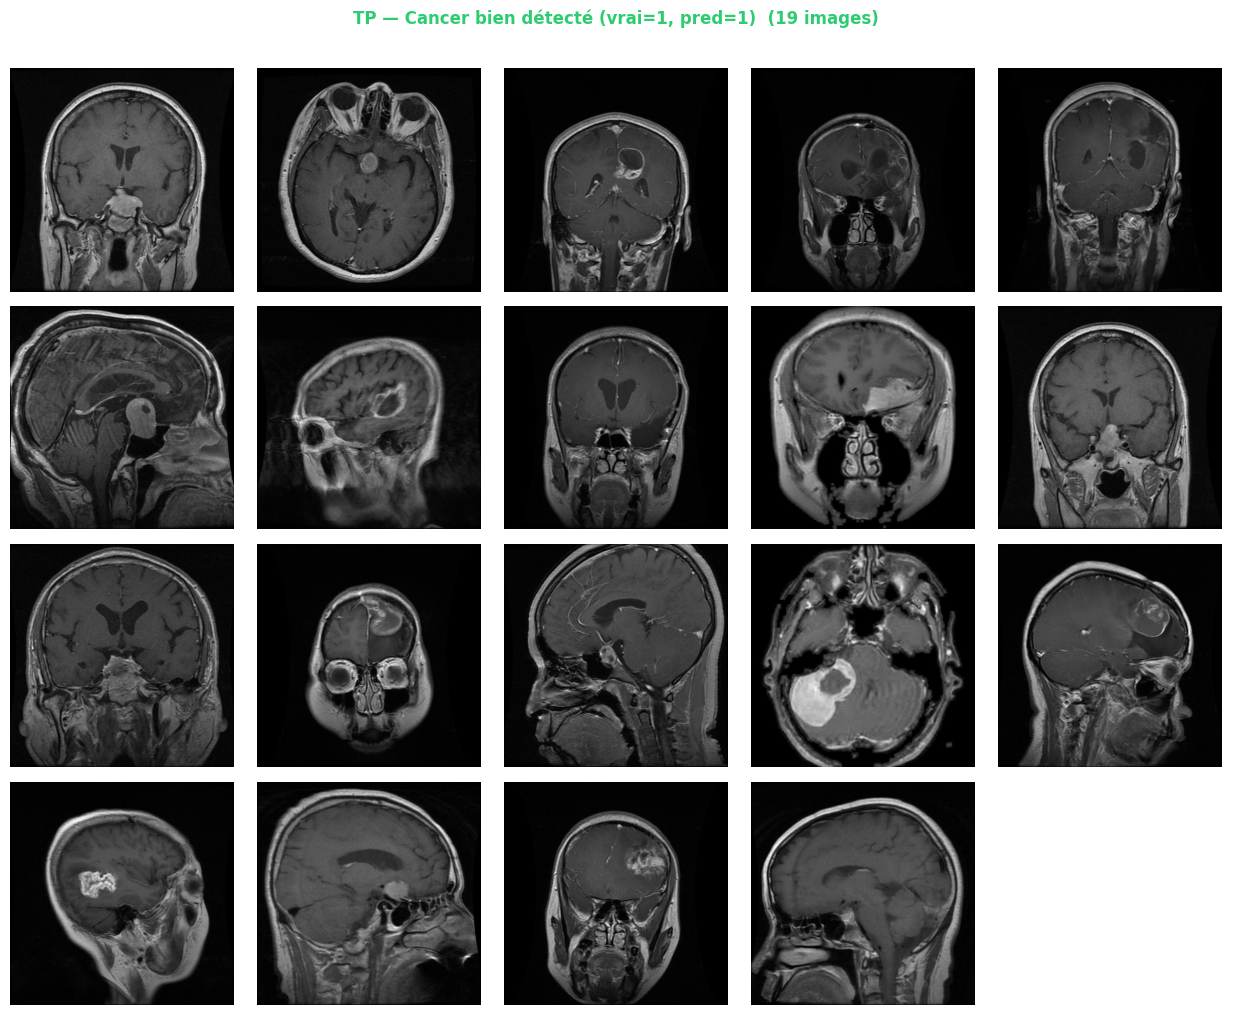

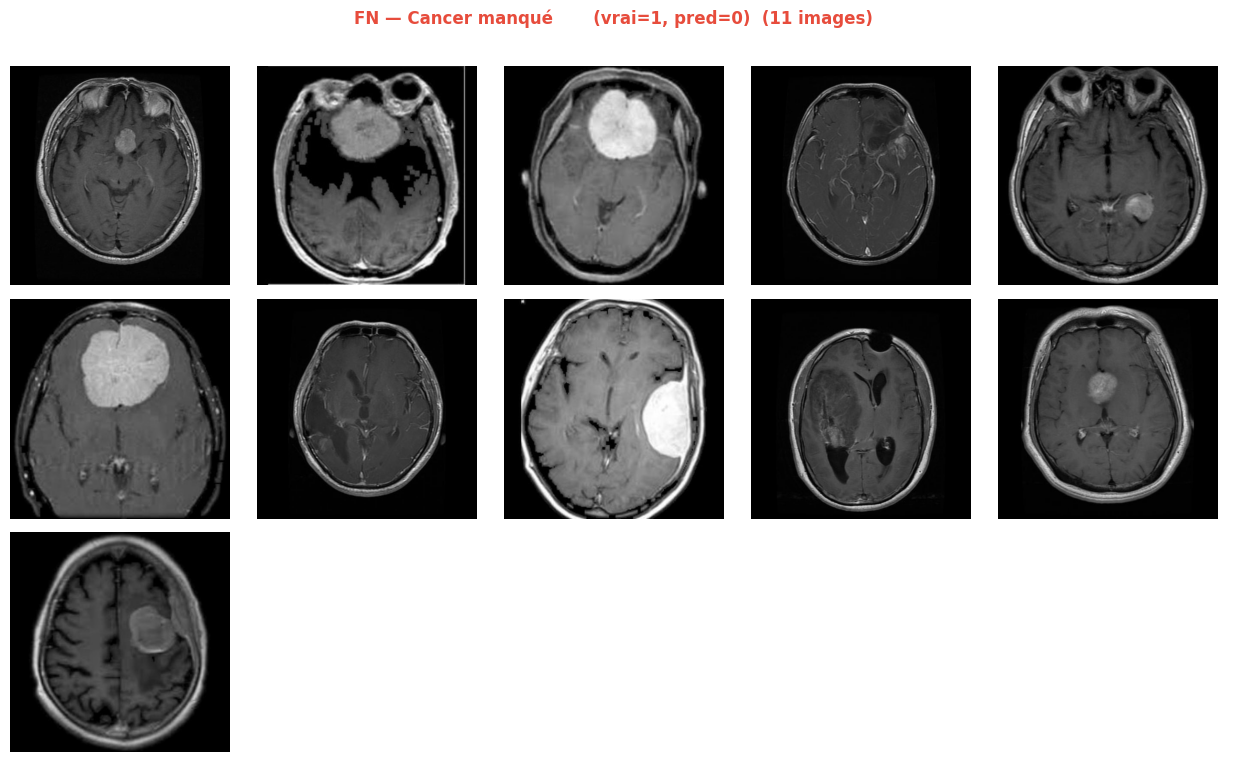

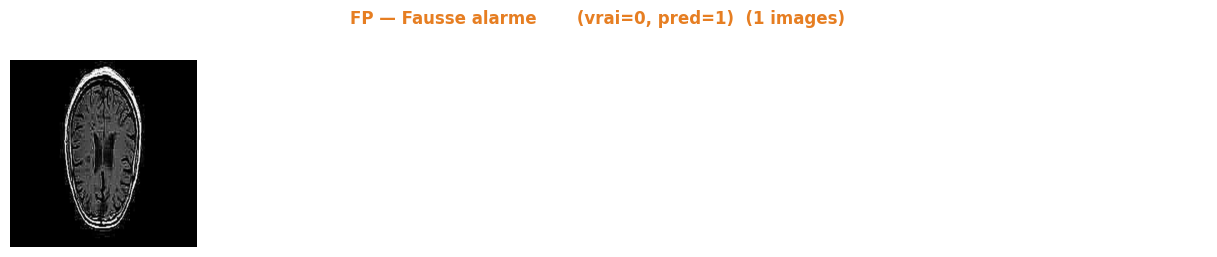

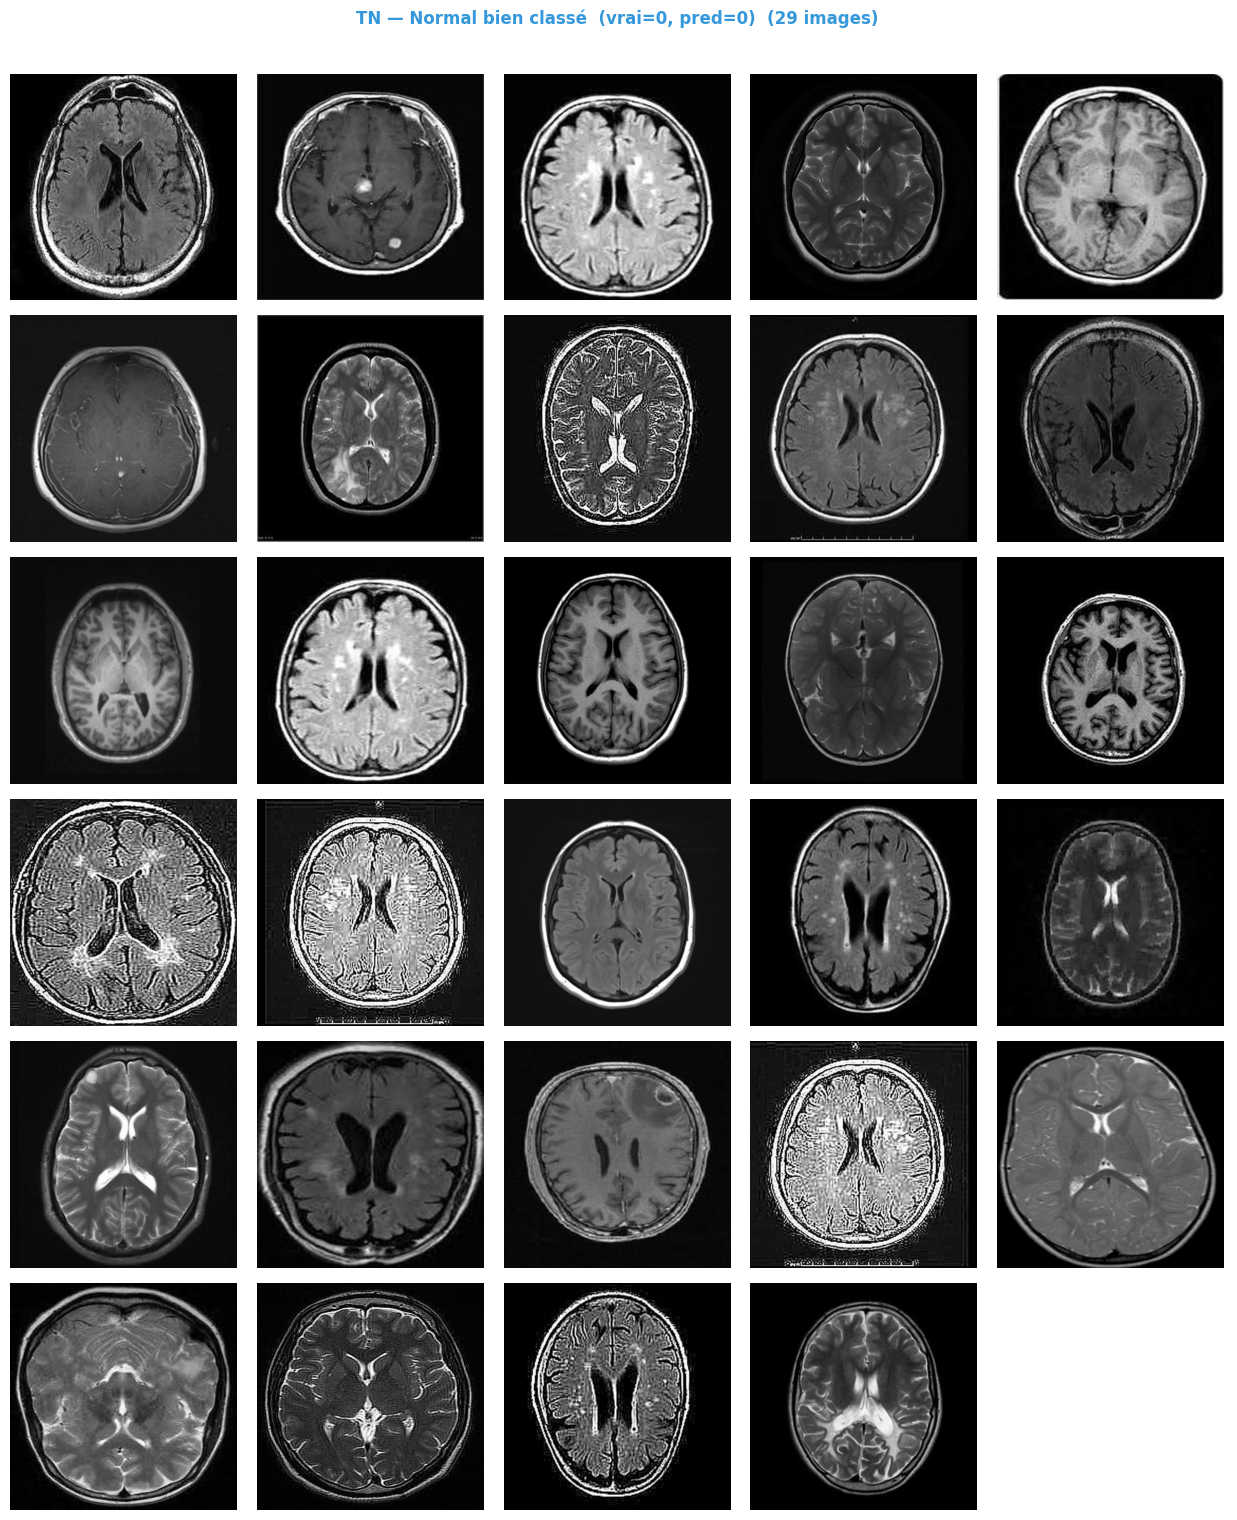

In [30]:
def plot_confusion_images(df, y_true, y_pred, n_cols=5):
    """
    Display val images grouped by confusion matrix quadrant.
    df      : DataFrame with image_path column (same order as y_true/y_pred)
    y_true  : list/array of true labels
    y_pred  : list/array of predicted labels
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    quadrants = {
        "TP — Cancer bien détecté (vrai=1, pred=1)": np.where((y_true == 1) & (y_pred == 1))[0],
        "FN — Cancer manqué       (vrai=1, pred=0)": np.where((y_true == 1) & (y_pred == 0))[0],
        "FP — Fausse alarme       (vrai=0, pred=1)": np.where((y_true == 0) & (y_pred == 1))[0],
        "TN — Normal bien classé  (vrai=0, pred=0)": np.where((y_true == 0) & (y_pred == 0))[0],
    }
    colors = {"TP": "#2ecc71", "FN": "#e74c3c", "FP": "#e67e22", "TN": "#3498db"}
    color_list = [colors["TP"], colors["FN"], colors["FP"], colors["TN"]]

    for (title, indices), color in zip(quadrants.items(), color_list):
        if len(indices) == 0:
            print(f"  {title} : aucune image\n")
            continue

        n_rows = (len(indices) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.5, n_rows * 2.5))
        fig.suptitle(f"{title}  ({len(indices)} images)", fontsize=12,
                     color=color, fontweight="bold", y=1.01)
        axes = np.array(axes).flatten()

        for i, idx in enumerate(indices):
            img = Image.open(df.iloc[idx]["image_path"]).convert("RGB")
            axes[i].imshow(img)
            axes[i].axis("off")
            for spine in axes[i].spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(3)

        for j in range(len(indices), len(axes)):
            axes[j].axis("off")

        plt.tight_layout()
        plt.show()

plot_confusion_images(
    labeled_val_df.reset_index(drop=True),
    all_labels,
    all_preds,
)

## Grad-CAM — Pourquoi le modèle se trompe ?

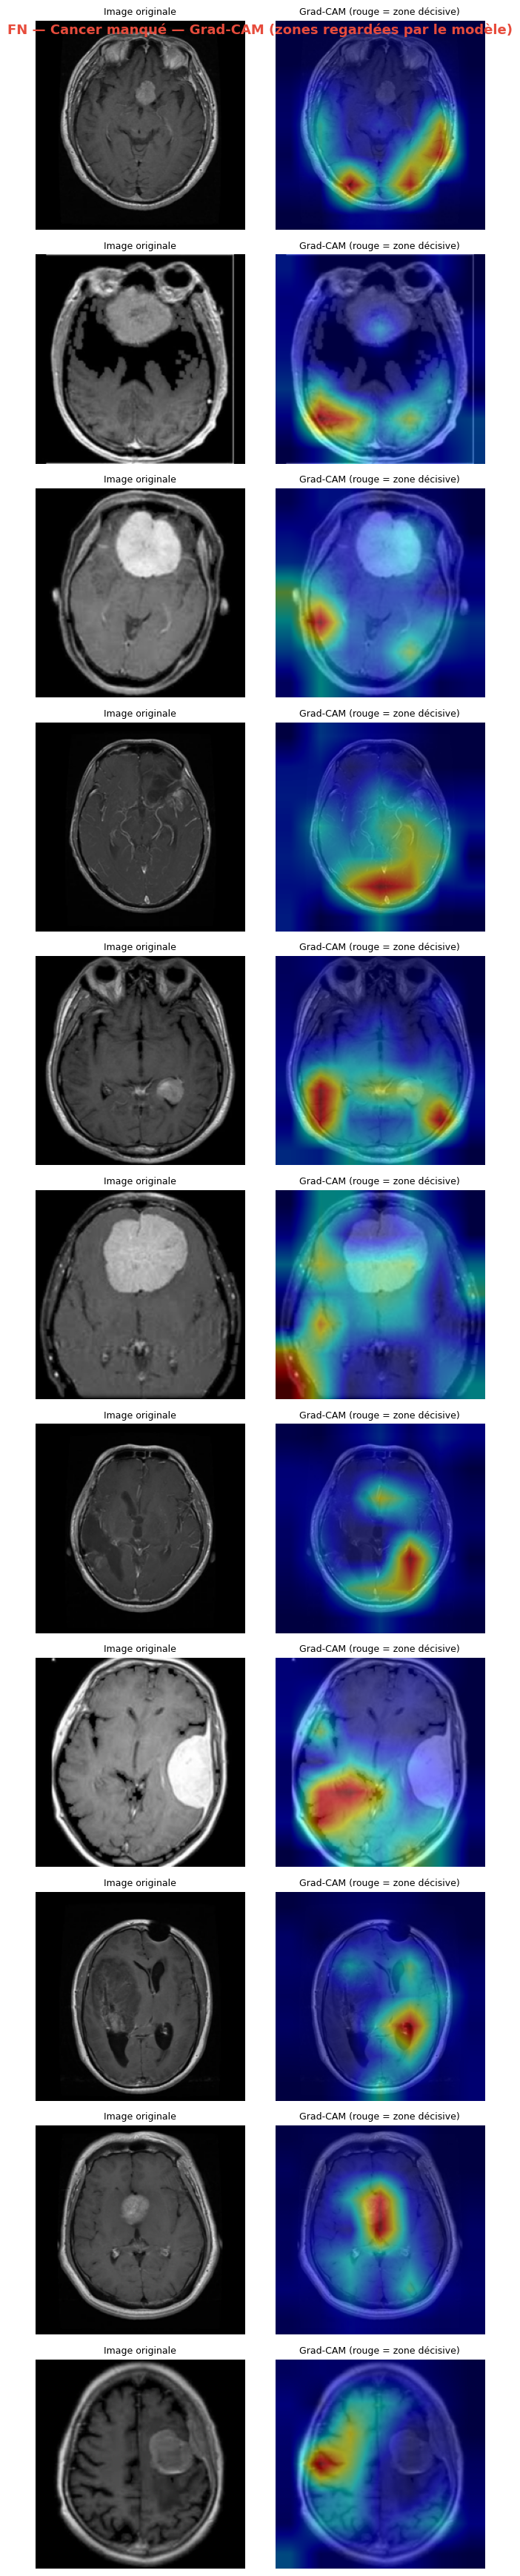

In [31]:
import cv2

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        self._fwd_handle = target_layer.register_forward_hook(
            lambda m, inp, out: setattr(self, "activations", out.detach())
        )
        self._bwd_handle = target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, "gradients", go[0].detach())
        )

    def remove(self):
        """Remove hooks — must be called before creating a new GradCAM on the same layer."""
        self._fwd_handle.remove()
        self._bwd_handle.remove()

    def __call__(self, img_tensor, class_idx):
        self.model.zero_grad()
        output = self.model(img_tensor)
        output[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1).squeeze()
        cam = torch.relu(cam)
        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()
        return cam.cpu().numpy()


def overlay_gradcam(img_path, cam, alpha=0.5):
    img = np.array(Image.open(img_path).convert("RGB").resize((224, 224)))
    heatmap = cv2.resize(cam, (224, 224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    blended = (alpha * heatmap + (1 - alpha) * img).astype(np.uint8)
    return img, blended


gradcam = GradCAM(model, target_layer=model.features[-1])


def plot_gradcam_errors(df, y_true, y_pred, gradcam_instance=None, error_type="FN"):
    """
    Plot Grad-CAM for misclassified images.
    gradcam_instance : GradCAM object to use (defaults to global gradcam)
    error_type       : 'FN' (cancer manqué) or 'FP' (fausse alarme)
    """
    gc = gradcam_instance if gradcam_instance is not None else gradcam

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    if error_type == "FN":
        indices = np.where((y_true == 1) & (y_pred == 0))[0]
        title_prefix = "FN — Cancer manqué"
        pred_class = 0
    else:
        indices = np.where((y_true == 0) & (y_pred == 1))[0]
        title_prefix = "FP — Fausse alarme"
        pred_class = 1

    if len(indices) == 0:
        print(f"Aucune erreur de type {error_type}.")
        return

    n_rows = len(indices)
    fig, axes = plt.subplots(n_rows, 2, figsize=(7, n_rows * 3.2))
    if n_rows == 1:
        axes = [axes]

    fig.suptitle(f"{title_prefix} — Grad-CAM (zones regardées par le modèle)",
                 fontsize=13, fontweight="bold", color="#e74c3c")

    gc.model.eval()
    for row, idx in enumerate(indices):
        img_path = df.iloc[idx]["image_path"]
        img_tensor = TRANSFORMS(Image.open(img_path).convert("RGB"))
        img_tensor = img_tensor.unsqueeze(0).to(DEVICE).requires_grad_(True)
        cam = gc(img_tensor, class_idx=pred_class)
        original, overlay = overlay_gradcam(img_path, cam)
        axes[row][0].imshow(original)
        axes[row][0].set_title("Image originale", fontsize=9)
        axes[row][0].axis("off")
        axes[row][1].imshow(overlay)
        axes[row][1].set_title("Grad-CAM (rouge = zone décisive)", fontsize=9)
        axes[row][1].axis("off")

    plt.tight_layout()
    plt.show()


plot_gradcam_errors(
    labeled_val_df.reset_index(drop=True),
    all_labels,
    all_preds,
    error_type="FN",
)

# Fine tuning sur labels forts

Phase 2 — fine-tuning on 70 strong labels

Epoch 01/20 — loss: 0.6252
Epoch 02/20 — loss: 0.6098
Epoch 03/20 — loss: 0.5517
Epoch 04/20 — loss: 0.5738
Epoch 05/20 — loss: 0.5228
Epoch 06/20 — loss: 0.6166
Epoch 07/20 — loss: 0.4553
Epoch 08/20 — loss: 0.4833
Epoch 09/20 — loss: 0.5004
Epoch 10/20 — loss: 0.4035

Modèle sauvegardé → model_phase2.pth
────────────────────────────────────────
  Phase 2 — Fine-tuning labels forts
────────────────────────────────────────
  Accuracy  : 0.8500
  Precision : 1.0000
  Recall    : 0.7000
  F1-score  : 0.8235
  F2-score  : 0.7447
  ARI       : 0.4820
────────────────────────────────────────



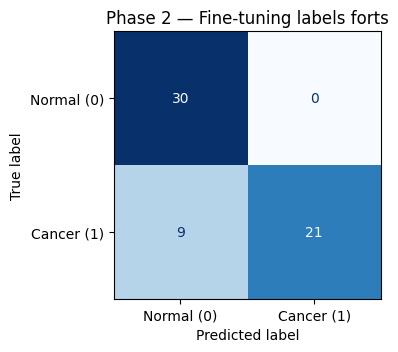


Grad-CAM — FN (cancers manqués) après fine-tuning :


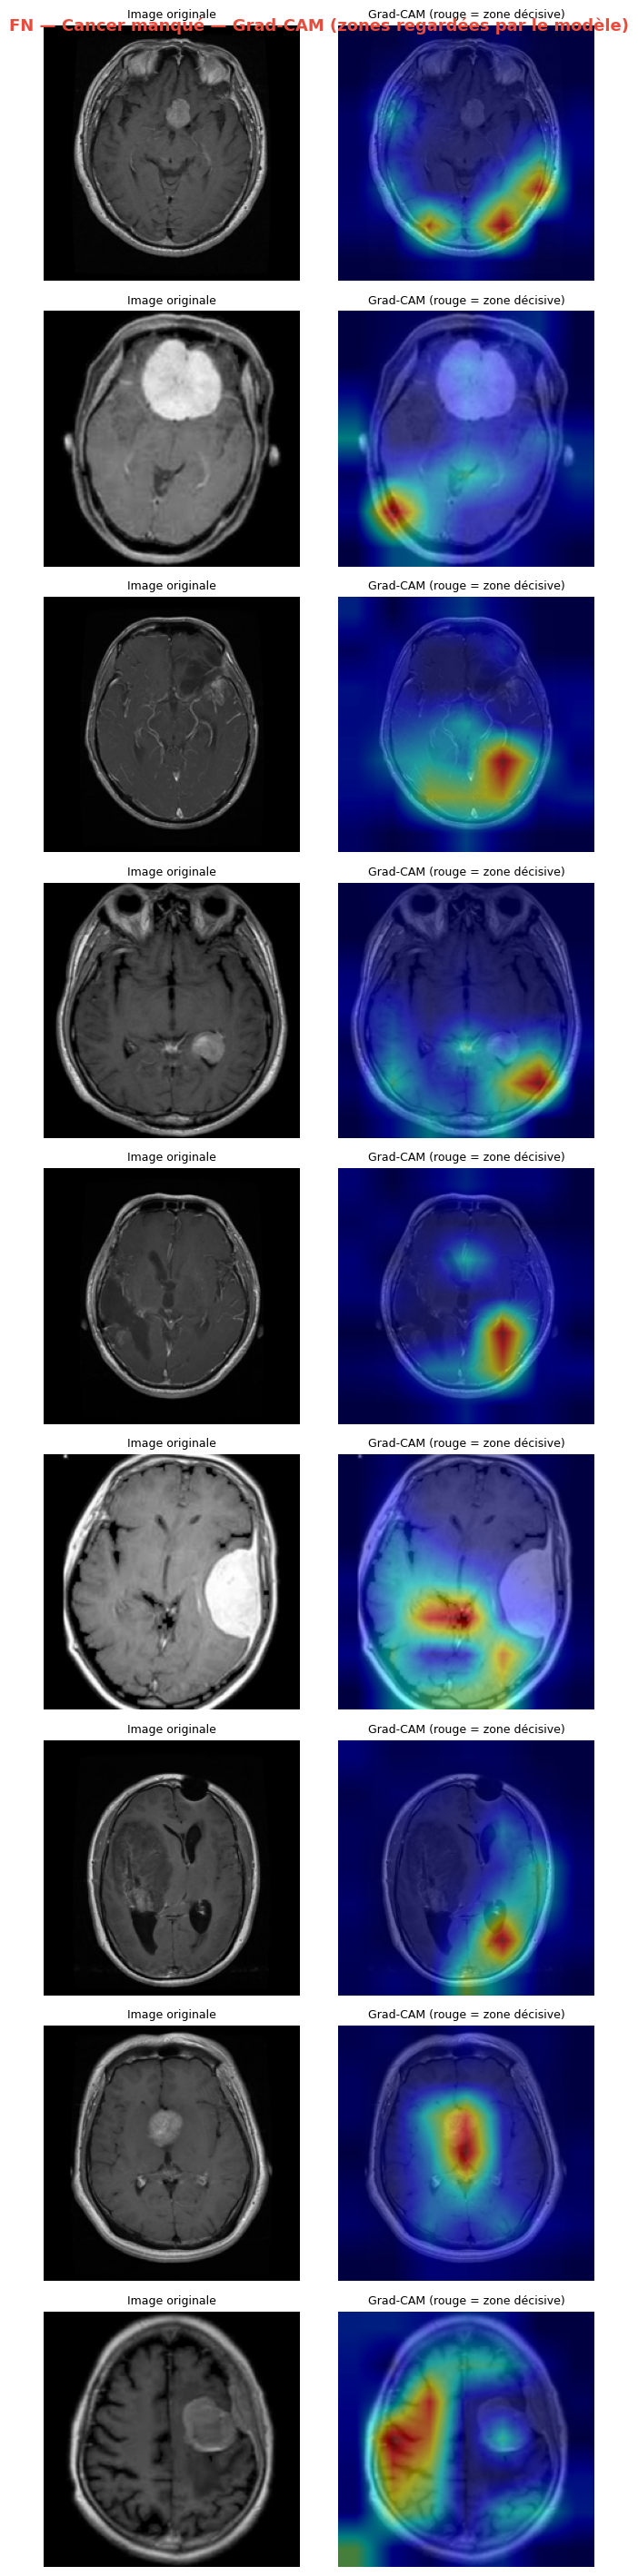


Grad-CAM — FP (fausses alarmes) après fine-tuning :
Aucune erreur de type FP.


In [32]:
# ── Phase 2 : Fine-tuning on strong labels (70 images) ──────────────────────

TRAIN_TRANSFORMS = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

loader_strong = DataLoader(
    MRIset(labeled_test_df, transform=TRAIN_TRANSFORMS),
    batch_size=8,
    shuffle=True,
)

# Unfreeze last 2 backbone blocks + head
# lr=5e-5 on backbone lets it meaningfully adapt from phase 1 warm start
for param in model.parameters():
    param.requires_grad = False
for param in model.features[-1].parameters():
    param.requires_grad = True
for param in model.features[-2].parameters():
    param.requires_grad = True
for param in model.classifier.parameters():
    param.requires_grad = True

optimizer_p2 = torch.optim.Adam([
    {"params": model.features[-1].parameters(), "lr": 5e-5},
    {"params": model.features[-2].parameters(), "lr": 5e-5},
    {"params": model.classifier.parameters(),   "lr": 1e-4},
])

criterion = nn.CrossEntropyLoss()

print("Phase 2 — fine-tuning on 70 strong labels\n")
for epoch in range(10):
    model.train()
    epoch_loss = 0.0
    for imgs, labels in loader_strong:
        imgs   = imgs.to(DEVICE)
        labels = labels.to(DEVICE).long()
        optimizer_p2.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_p2.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1:02d}/20 — loss: {epoch_loss / len(loader_strong):.4f}")

torch.save(model.state_dict(), "model_phase2.pth")
print("\nModèle sauvegardé → model_phase2.pth")

# ── Inference on val set ──────────────────────────────────────────────────────
all_preds_p2  = []
all_labels_p2 = []

model.eval()
with torch.no_grad():
    for imgs, labels in loader_val:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        preds   = torch.argmax(outputs, dim=1)
        all_preds_p2.extend(preds.cpu().numpy())
        all_labels_p2.extend(labels.numpy())

results_p2 = evaluate(all_labels_p2, all_preds_p2, title="Phase 2 — Fine-tuning labels forts")

# Remove phase 1 hooks before creating phase 2 GradCAM on the same layer
gradcam.remove()
gradcam_p2 = GradCAM(model, target_layer=model.features[-1])

print("\nGrad-CAM — FN (cancers manqués) après fine-tuning :")
plot_gradcam_errors(labeled_val_df.reset_index(drop=True), all_labels_p2, all_preds_p2,
                    gradcam_instance=gradcam_p2, error_type="FN")
print("\nGrad-CAM — FP (fausses alarmes) après fine-tuning :")
plot_gradcam_errors(labeled_val_df.reset_index(drop=True), all_labels_p2, all_preds_p2,
                    gradcam_instance=gradcam_p2, error_type="FP")

# Entrainement completement supervisé

Supervisé pur — entraînement sur 70 images

Epoch 01/20 — loss: 0.6644
Epoch 02/20 — loss: 0.5922
Epoch 03/20 — loss: 0.5375
Epoch 04/20 — loss: 0.4801
Epoch 05/20 — loss: 0.4343
Epoch 06/20 — loss: 0.4170
Epoch 07/20 — loss: 0.4571
Epoch 08/20 — loss: 0.3938
Epoch 09/20 — loss: 0.3711
Epoch 10/20 — loss: 0.3910
Epoch 11/20 — loss: 0.3217
Epoch 12/20 — loss: 0.3622
Epoch 13/20 — loss: 0.2809
Epoch 14/20 — loss: 0.3444
Epoch 15/20 — loss: 0.3024
Epoch 16/20 — loss: 0.3379
Epoch 17/20 — loss: 0.2786
Epoch 18/20 — loss: 0.2404
Epoch 19/20 — loss: 0.2157
Epoch 20/20 — loss: 0.3279

Modèle sauvegardé → model_supervised.pth
────────────────────────────────────────
  Supervisé pur — 70 labels forts
────────────────────────────────────────
  Accuracy  : 0.7833
  Precision : 0.9474
  Recall    : 0.6000
  F1-score  : 0.7347
  F2-score  : 0.6475
  ARI       : 0.3110
────────────────────────────────────────



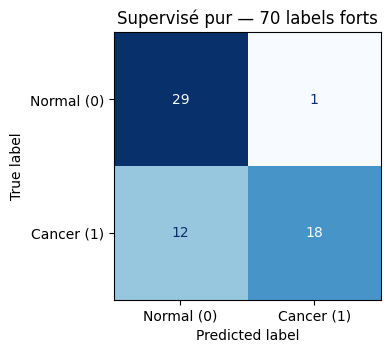

In [33]:
# ── Fully supervised baseline — fresh model, 70 strong labels only ───────────

# Re-initialize from ImageNet weights — no influence from phase 1 or 2
model_sup = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1)
model_sup.classifier = ClassifierHead().to(DEVICE)
model_sup = model_sup.to(DEVICE)

# Freeze backbone, train head only (same setup as phase 1)
for param in model_sup.parameters():
    param.requires_grad = False
for param in model_sup.classifier.parameters():
    param.requires_grad = True

optimizer_sup = torch.optim.Adam(model_sup.classifier.parameters(), lr=1e-3)
criterion_sup = nn.CrossEntropyLoss()

# loader_strong already exists (70 images, augmented, batch_size=8)
print("Supervisé pur — entraînement sur 70 images\n")
for epoch in range(20):
    model_sup.train()
    epoch_loss = 0.0
    for imgs, labels in loader_strong:
        imgs   = imgs.to(DEVICE)
        labels = labels.to(DEVICE).long()
        optimizer_sup.zero_grad()
        outputs = model_sup(imgs)
        loss = criterion_sup(outputs, labels)
        loss.backward()
        optimizer_sup.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1:02d}/20 — loss: {epoch_loss / len(loader_strong):.4f}")

torch.save(model_sup.state_dict(), "model_supervised.pth")
print("\nModèle sauvegardé → model_supervised.pth")

# ── Inference on val set ──────────────────────────────────────────────────────
all_preds_sup  = []
all_labels_sup = []

model_sup.eval()
with torch.no_grad():
    for imgs, labels in loader_val:
        imgs = imgs.to(DEVICE)
        outputs = model_sup(imgs)
        preds   = torch.argmax(outputs, dim=1)
        all_preds_sup.extend(preds.cpu().numpy())
        all_labels_sup.extend(labels.numpy())

# ── Evaluate ──────────────────────────────────────────────────────────────────
results_sup = evaluate(all_labels_sup, all_preds_sup, title="Supervisé pur — 70 labels forts")



Grad-CAM — FN (cancers manqués) — supervisé pur :


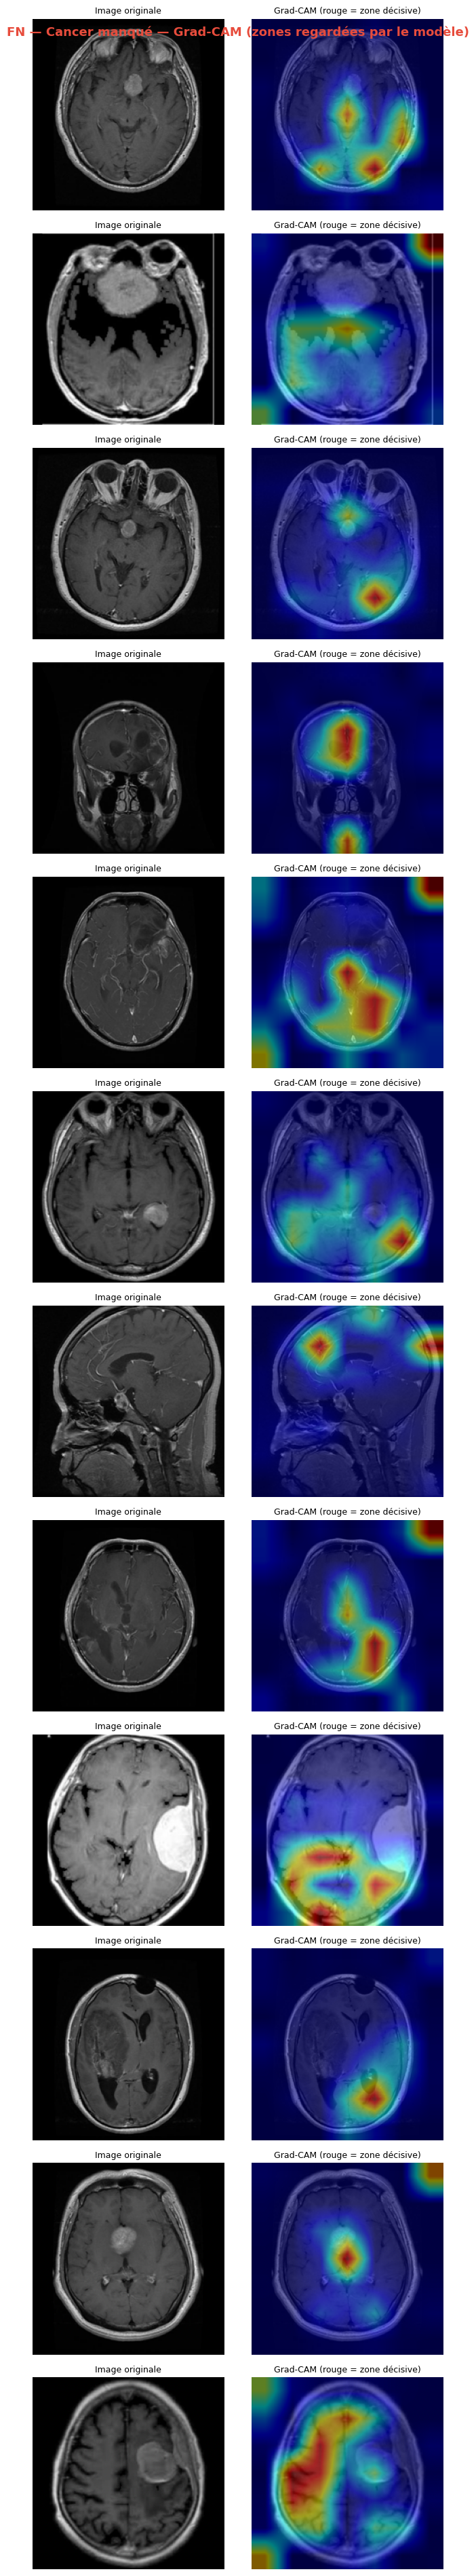

Grad-CAM — FP (fausses alarmes) — supervisé pur :


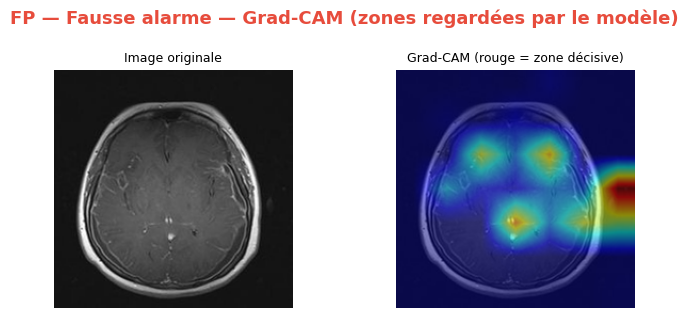

In [34]:
# Remove phase 2 hooks before creating supervised GradCAM on the same layer
gradcam_p2.remove()
gradcam_sup = GradCAM(model_sup, target_layer=model_sup.features[-1])

print("Grad-CAM — FN (cancers manqués) — supervisé pur :")
plot_gradcam_errors(labeled_val_df.reset_index(drop=True), all_labels_sup, all_preds_sup,
                    gradcam_instance=gradcam_sup, error_type="FN")
print("Grad-CAM — FP (fausses alarmes) — supervisé pur :")
plot_gradcam_errors(labeled_val_df.reset_index(drop=True), all_labels_sup, all_preds_sup,
                    gradcam_instance=gradcam_sup, error_type="FP")

In [35]:
# ── Recap comparatif ──────────────────────────────────────────────────────────
print("\n" + "═"*50)
print("  COMPARAISON DES 3 APPROCHES (val set, 30 images)")
print("═"*50)
rows = [
    ("Phase 1 — pseudo-labels (1406)",  results),
    ("Phase 2 — fine-tuning (1406+70)", results_p2),
    ("Phase 3 — Supervisé pur (70)",              results_sup),
]
print(f"{'Modèle':<35} {'Acc':>6} {'Rec':>6} {'F2':>6} {'ARI':>6}")
print("─"*57)
for name, r in rows:
    print(f"{name:<35} {r['accuracy']:>6.3f} {r['recall']:>6.3f} {r['f2']:>6.3f} {r['ari']:>6.3f}")


══════════════════════════════════════════════════
  COMPARAISON DES 3 APPROCHES (val set, 30 images)
══════════════════════════════════════════════════
Modèle                                 Acc    Rec     F2    ARI
─────────────────────────────────────────────────────────
Phase 1 — pseudo-labels (1406)       0.800  0.633  0.679  0.350
Phase 2 — fine-tuning (1406+70)      0.850  0.700  0.745  0.482
Phase 3 — Supervisé pur (70)         0.783  0.600  0.647  0.311
